In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict
from tqdm import tqdm

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer
import matplotlib.pyplot as plt

#device = torch.device('cuda') if torch.cuda.is_available() else (torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'))
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Training Data

Text(0.5, 1.0, 'Training Data')

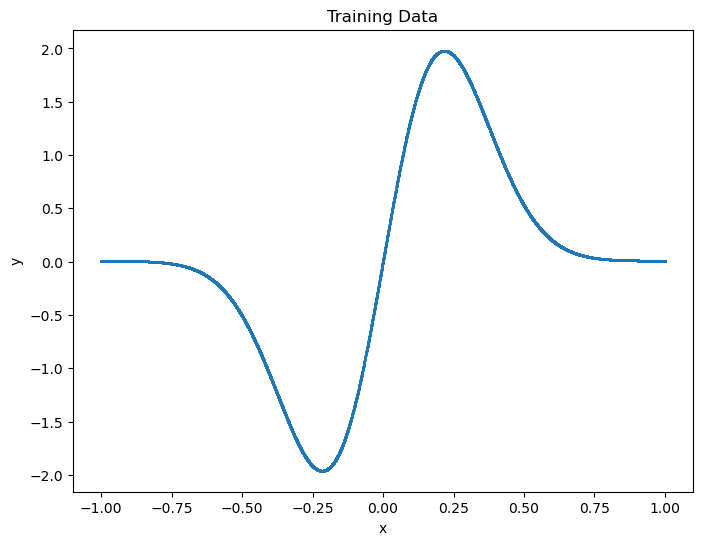

In [2]:
from torch.utils.data import DataLoader, TensorDataset

def func(x):
    return torch.exp(-10*x**2)*torch.sin(2*x)

xtrain = 2*torch.rand(10_000,1) - 1 # U[-1,1]
xtest = 2*torch.rand(10_000,1) - 1
xval = 2*torch.rand(10_000,1) - 1

ytrain = func(xtrain)
ytest = func(xtest)
yval = func(xval)

mean, std = ytrain.mean(), ytrain.std()
ytrain = (ytrain - mean) / std
ytest = (ytest - mean) / std
yval = (yval - mean) / std

batch_size = 128

train_dataset = TensorDataset(xtrain, ytrain)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(xval, yval)
val_loader = DataLoader(val_dataset, batch_size=10_000, shuffle=False)
test_dataset = TensorDataset(xtest, ytest)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# plot training data
plt.figure(figsize=(8, 6))
plt.scatter(xtrain.numpy(), ytrain.numpy(), s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')

# Define models

In [3]:
input_dim = 1
hidden_dims = [16,16,16]
output_dim = 1

mlp_adam = MLP(input_dim,hidden_dims,output_dim).to(device)
mlp_svd = MLP(input_dim,hidden_dims,output_dim).to(device)

# Train MLP w/ Adam

In [4]:
optimizer = torch.optim.Adam(mlp_adam.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
num_epochs = 100
losses_adam = defaultdict(list)
for epoch in tqdm(range(num_epochs)):
    epoch_losses = defaultdict(list)
    mlp_adam.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = mlp_adam(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    mlp_adam.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = mlp_adam(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
    # Save batch-wise losses
    losses_adam['train_batch'].extend(epoch_losses['train'])
    losses_adam['val_batch'].extend(epoch_losses['val'])
    for k,v in epoch_losses.items():
        losses_adam[k].append(np.mean(v))

100%|██████████| 100/100 [00:07<00:00, 13.65it/s]


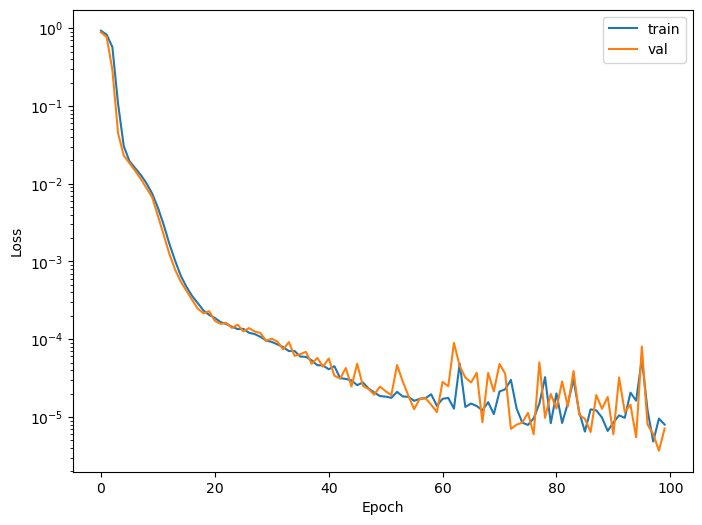

In [5]:
plt.figure(figsize=(8,6))
plt.plot(losses_adam['train'], label='train')
plt.plot(losses_adam['val'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# Train MLP w/ SVD-SGD

In [6]:
# MSE loss function
def loss_fn(pred,y):
    loss = (pred-y)**2
    loss = loss.sum(dim=-1) # shape (B,)
    return loss

lr_svd = 0.1
k_svd = batch_size // 2
rtol = 1e-3
num_epochs = 100

model_svd = FunctionalModelJac(mlp_svd,loss_fn)
opt_svd = SVDOptimizer(model_svd,lr=lr_svd,k=k_svd,rtol=rtol)

losses_svd = defaultdict(list)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in tqdm(range(num_epochs)):
        epoch_losses = defaultdict(list)
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses = model_svd.loss_and_grad(batch)
            opt_svd.step()
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = model_svd.evaluate(xb)
            loss = loss_fn(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

  0%|          | 0/100 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


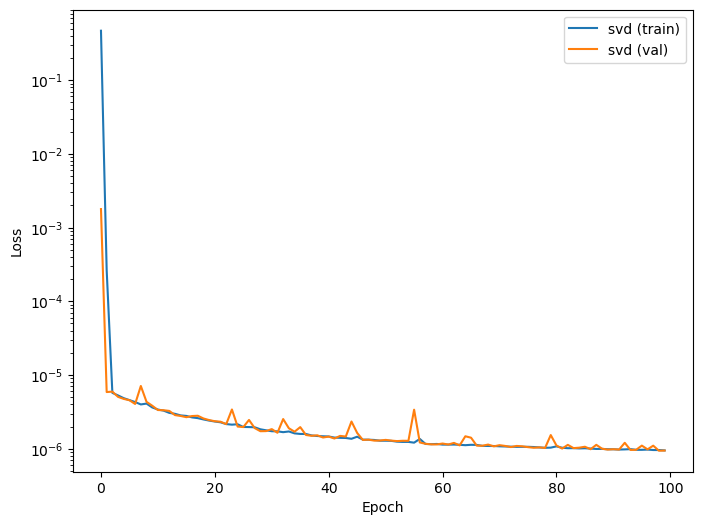

In [7]:
plt.figure(figsize=(8,6))
plt.plot(losses_svd['train'], label='svd (train)',color="C0")
plt.plot(losses_svd['val'], label='svd (val)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# Compare Adam vs SVD-SGD

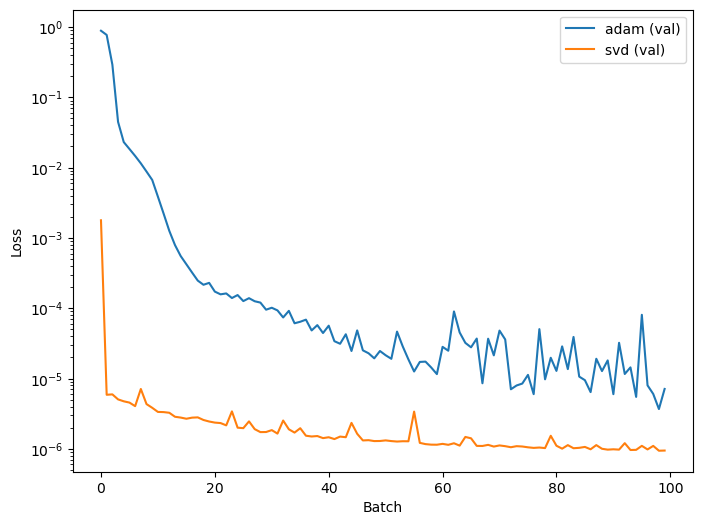

In [8]:
plt.figure(figsize=(8,6))
plt.plot(losses_adam['val'], label='adam (val)',color="C0")
plt.plot(losses_svd['val'], label='svd (val)',color="C1")
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()